In [47]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from src.resource_estimates.gate_costs.free_fermionic import Occupation
from src.resource_estimates.gate_costs.FFFT import FFFT
from src.resource_estimates.gate_costs.interactions import ShiftedOccupationPair
from src.resource_estimates.gate_costs.hubbard_commutators import SpinSymmetricMixedControlledHappa, SpinSymmetricMixedControlledKappa
from src.resource_estimates.gate_costs.hamming_weight_phasing import HWPGate

from src.hubbard_models.split_operator_error_coefficients import (
    plaquette_second_order_split_operator_error_coefficient,
    fourth_order_suzuki_trotter_split_operator_error_coefficient,
    fourth_order_augmented_split_operator_error_coefficients,
)

from src.resource_estimates.hamiltonian_simulation import hamiltonian_simulation_cost
from src.resource_estimates.quantum_phase_estimation import adaptive_phase_estimation_resources

In [56]:
tau = 0.5
U = 4
x = 0.01

def trotter_gates_2nd_order(logn: int, D: int) -> tuple[dict,...]:
    n = 2**logn
    N = n**D
    return {
        HWPGate({ShiftedOccupationPair(): N}, N): 1,
        HWPGate({FFFT(logn, D, 1):1}, n): 2,
        Occupation(): 2*N,
    },{
        HWPGate({ShiftedOccupationPair(): N}, N): 1
    }

def trotter_gates_4th_order(logn: int, D: int) -> tuple[dict,...]:
    n = 2**logn
    N = n**D
    return {
        HWPGate({ShiftedOccupationPair(): N}, N): 5,
        HWPGate({FFFT(logn, D, 1):1}, n): 5,
        Occupation(): 5*2*N
    },{
        HWPGate({ShiftedOccupationPair(): N}, N): 1
    }

def augmented_gates(logn: int, D: int) -> tuple[dict,...]:
    n = 2**logn
    N = n**D
    return {
        HWPGate({ShiftedOccupationPair(): N}, N): 1,
        HWPGate({FFFT(logn, D, 1):1}, n): 2,
        Occupation(): 2*N,
        HWPGate({SpinSymmetricMixedControlledHappa(): N // 2}, N //2): 2*D
    },{
        HWPGate({FFFT(logn, D, 1):1}, n): 2,
        Occupation(): 2*N,
        HWPGate({SpinSymmetricMixedControlledKappa(): N // 2}, N //2): 2*D
    }

def augmented_gates_trotter(logn: int, D: int) -> tuple[dict,...]:
    n = 2**logn
    N = n**D
    return {
        HWPGate({ShiftedOccupationPair(): N}, N): 1,
        HWPGate({FFFT(logn, D, 1):1}, n): 2,
        Occupation(): 2*N,
        HWPGate({SpinSymmetricMixedControlledHappa(): N // 2}, N //2): 2*D
    },{
        HWPGate({FFFT(logn, D, 1):1}, n): 2,
        Occupation(): 2*N,
        HWPGate({SpinSymmetricMixedControlledKappa(): N // 2}, N //2): 2*D*2
    }

gate_gens_1 = [trotter_gates_2nd_order, trotter_gates_4th_order, augmented_gates_trotter]
gate_gens_2 = [trotter_gates_2nd_order, trotter_gates_4th_order, augmented_gates]

def dict_to_t_count(dct: dict) -> int:
    tc = 0
    if "t" in dct.keys():
        tc += dct["t"] 
        
    if "tdg" in dct.keys():
        tc += dct["tdg"] 
        
    if "toffoli" in dct.keys():
        tc += 4*dct["toffoli"]
    return tc

In [57]:
def get_error_coefficients(n: int, D: int, U: float, tau: float, label: str, unitary_decomp: bool = True) -> dict:
    N = n**D
    match label:
        case "SO-FFFT 2":
            hopping_graph = nx.grid_graph([n]*D, periodic=True)
            return {3: plaquette_second_order_split_operator_error_coefficient(U, tau, N, hopping_graph)}
        case "SO-FFFT 4":
            return {5: fourth_order_suzuki_trotter_split_operator_error_coefficient(tau, U, N, 2*D)}
        case "SO-FFFT Augmented":
            return {5 + i: x for i,x in enumerate(fourth_order_augmented_split_operator_error_coefficients(U, tau, N, 2*D, unitary_decomp))}

# Hamiltonian simulation:

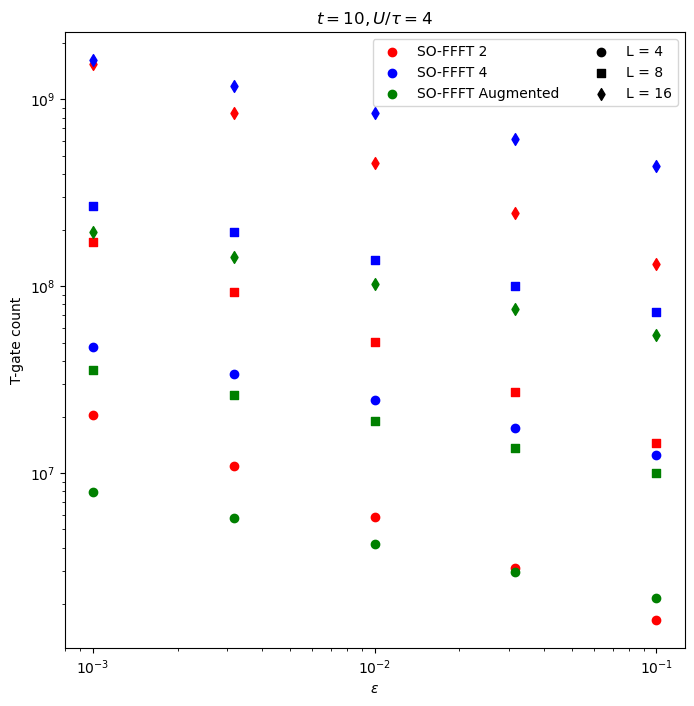

In [58]:
t = 10
D = 2
logeps_list = np.linspace(-3, -1, 5)
eps_list = np.pow(10, logeps_list)
Ls = [4, 8, 16]

colors = ['r', 'b', 'g']
marker_styles = ['o', 's', 'd']
comp_strats = ["SO-FFFT 2", "SO-FFFT 4", "SO-FFFT Augmented"]

fig, ax = plt.subplots(figsize = (8, 8))

for strat, color in zip(comp_strats, colors):
    ax.scatter([],[], c = color, marker = "o", label = strat)
    
for L, marker in zip(Ls, marker_styles):
    ax.scatter([],[], c = "k", marker = marker, label = f"L = {L}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.legend(ncol = 2)
ax.set_xlabel(rf"$\varepsilon$")
ax.set_ylabel(f"T-gate count")
ax.legend(ncol = 2)
ax.set_title(rf"$t = {t}, U / \tau = {U}$")

for gate_gen, color, comp_strat in zip(gate_gens_1, colors, comp_strats):
    for L, marker_style in zip(Ls, marker_styles):
        t_gates, u_gates = gate_gen(int(np.log2(L)), D)
        dcts = [hamiltonian_simulation_cost(
            t, 
            e, 
            t_gates, 
            outer_gates=u_gates, 
            error_coefficients=get_error_coefficients(L, D, U, tau, comp_strat, True),
            x=x,
            synthesize_rotation_with="RUS"
        )
            for e in eps_list
               ]
        ys = [dict_to_t_count(d) for d in dcts]
        ax.scatter(eps_list, ys, marker = marker_style, c = color)

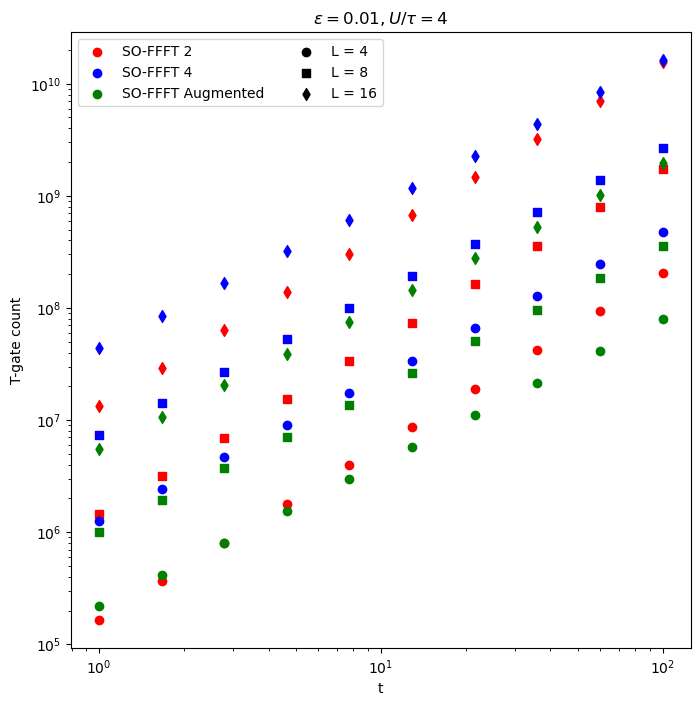

In [67]:
D = 2
logts = np.linspace(0, 2, 10)
ts = np.pow(10, logts)
eps = 0.01
Ls = [4, 8, 16]

colors = ['r', 'b', 'g']
marker_styles = ['o', 's', 'd']
comp_strats = ["SO-FFFT 2", "SO-FFFT 4", "SO-FFFT Augmented"]

fig, ax = plt.subplots(figsize = (8, 8))

for strat, color in zip(comp_strats, colors):
    ax.scatter([],[], c = color, marker = "o", label = strat)
    
for L, marker in zip(Ls, marker_styles):
    ax.scatter([],[], c = "k", marker = marker, label = f"L = {L}")

ax.set_xscale("log")
ax.set_yscale("log")
ax.legend(ncol = 2)
ax.set_xlabel(rf"t")
ax.set_ylabel(f"T-gate count")
ax.legend(ncol = 2)
ax.set_title(rf"$\varepsilon = {eps}, U / \tau = {U}$")

for gate_gen, color, comp_strat in zip(gate_gens_1, colors, comp_strats):
    for L, marker_style in zip(Ls, marker_styles):
        t_gates, u_gates = gate_gen(int(np.log2(L)), D)
        dcts = [hamiltonian_simulation_cost(
            t, 
            eps, 
            t_gates, 
            outer_gates=u_gates, 
            error_coefficients=get_error_coefficients(L, D, U, tau, comp_strat, True),
            x=x,
            synthesize_rotation_with="RUS"
        )
            for t in ts
               ]
        ys = [dict_to_t_count(d) for d in dcts]
        ax.scatter(ts, ys, marker = marker_style, c = color)

# Quantum Phase Estimation

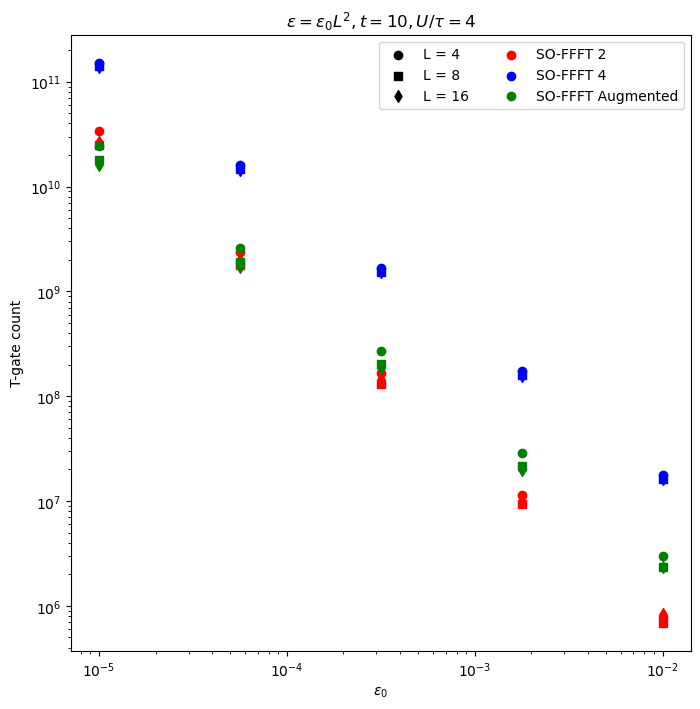

In [62]:
D = 2
logeps_list = np.linspace(-5, -2, 5)
eps_list = np.pow(10, logeps_list)
Ls = [4, 8, 16]

colors = ['r', 'b', 'g']
marker_styles = ['o', 's', 'd']
comp_strats = ["SO-FFFT 2", "SO-FFFT 4", "SO-FFFT Augmented"]

fig, ax = plt.subplots(figsize = (8, 8))

for L, marker in zip(Ls, marker_styles):
    ax.scatter([],[], c = "k", marker = marker, label = f"L = {L}")
for strat, color in zip(comp_strats, colors):
    ax.scatter([],[], c = color, marker = "o", label = strat)

ax.set_xscale("log")
ax.set_yscale("log")
ax.legend(ncol = 2)
ax.set_xlabel(rf"$\varepsilon_0$")
ax.set_ylabel(f"T-gate count")
ax.legend(ncol = 2)
ax.set_title(rf"$\varepsilon = \varepsilon_0L^2, t = {t}, U / \tau = {U}$")

for gate_gen, color, comp_strat in zip(gate_gens, colors, comp_strats):
    for L, marker_style in zip(Ls, marker_styles):
        t_gates, u_gates = gate_gen(int(np.log2(L)), D)
        dcts = [adaptive_phase_estimation_resources(
            e * L**2, 
            t_gates, 
            unitary_gates=u_gates, 
            unitary_error_coefficients=get_error_coefficients(L, D, U, tau, comp_strat, False),
            x=x,
            synthesize_rotation_with="RUS"
        )
            for e in eps_list
               ]
        ys = [dict_to_t_count(d) for d in dcts]
        ax.scatter(eps_list, ys, marker = marker_style, c = color)

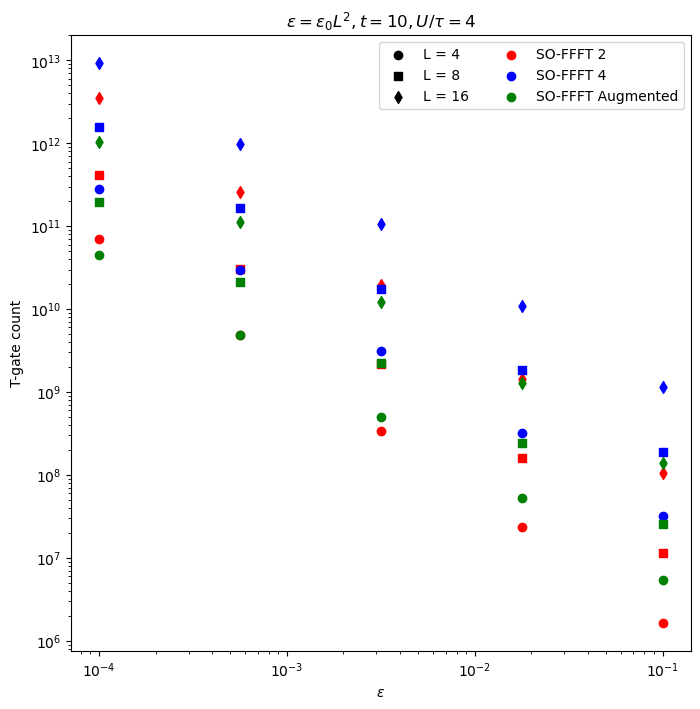

In [61]:
D = 2
logeps_list = np.linspace(-4, -1, 5)
eps_list = np.pow(10, logeps_list)
Ls = [4, 8, 16]

colors = ['r', 'b', 'g']
marker_styles = ['o', 's', 'd']
comp_strats = ["SO-FFFT 2", "SO-FFFT 4", "SO-FFFT Augmented"]

fig, ax = plt.subplots(figsize = (8, 8))

for L, marker in zip(Ls, marker_styles):
    ax.scatter([],[], c = "k", marker = marker, label = f"L = {L}")
for strat, color in zip(comp_strats, colors):
    ax.scatter([],[], c = color, marker = "o", label = strat)

ax.set_xscale("log")
ax.set_yscale("log")
ax.legend(ncol = 2)
ax.set_xlabel(rf"$\varepsilon$")
ax.set_ylabel(f"T-gate count")
ax.legend(ncol = 2)
ax.set_title(rf"$\varepsilon = \varepsilon_0L^2, t = {t}, U / \tau = {U}$")

for gate_gen, color, comp_strat in zip(gate_gens, colors, comp_strats):
    for L, marker_style in zip(Ls, marker_styles):
        t_gates, u_gates = gate_gen(int(np.log2(L)), D)
        dcts = [adaptive_phase_estimation_resources(
            e, 
            t_gates, 
            unitary_gates=u_gates, 
            unitary_error_coefficients=get_error_coefficients(L, D, U, tau, comp_strat, False),
            x=x,
            synthesize_rotation_with="RUS"
        )
            for e in eps_list
               ]
        ys = [dict_to_t_count(d) for d in dcts]
        ax.scatter(eps_list, ys, marker = marker_style, c = color)